Датасет Rain in Australia 
https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package

На основании набора данных нужно предсказать, пойдёт ли дождь на следующий день. Целевая переменная: RainTomorrow. По описаниям датасета рекомендовано использование хронологического разделения на обучающую и тестовую выборки. Порог, при котором присваивается значение "да" - выпадение осадков в течении суток до 9 утра более чем на 1 мм.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

**1. Загрузка данных** 

In [2]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")
print("Path to dataset files:", path)

# список всех файлов в папке
files = os.listdir(path)
print("Files in dataset:", files)

csv_file = os.path.join(path, 'weatherAUS.csv')
df = pd.read_csv(csv_file)

Path to dataset files: /kaggle/input/datasets/jsphyg/weather-dataset-rattle-package
Files in dataset: ['weatherAUS.csv']


In [3]:
df.shape

(145460, 23)

In [4]:
print("Все колонки: ", df.columns.tolist())
df.info()

Все колонки:  ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232

2. EDA

In [5]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [6]:
df.describe().round(2)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.00,144199.00,142199.00,82670.00,75625.00,135197.00,143693.00,142398.00,142806.00,140953.00,130395.00,130432.00,89572.00,86102.00,143693.00,141851.00
mean,12.19,23.22,2.36,5.47,7.61,40.04,14.04,18.66,68.88,51.54,1017.65,1015.26,4.45,4.51,16.99,21.68
std,6.40,7.12,8.48,4.19,3.79,13.61,8.92,8.81,19.03,20.80,7.11,7.04,2.89,2.72,6.49,6.94
min,-8.50,-4.80,0.00,0.00,0.00,6.00,0.00,0.00,0.00,0.00,980.50,977.10,0.00,0.00,-7.20,-5.40
25%,7.60,17.90,0.00,2.60,4.80,31.00,7.00,13.00,57.00,37.00,1012.90,1010.40,1.00,2.00,12.30,16.60
50%,12.00,22.60,0.00,4.80,8.40,39.00,13.00,19.00,70.00,52.00,1017.60,1015.20,5.00,5.00,16.70,21.10
75%,16.90,28.20,0.80,7.40,10.60,48.00,19.00,24.00,83.00,66.00,1022.40,1020.00,7.00,7.00,21.60,26.40
max,33.90,48.10,371.00,145.00,14.50,135.00,130.00,87.00,100.00,100.00,1041.00,1039.60,9.00,9.00,40.20,46.70


Судя по describe есть выбросы (371 у Rainfall при среднем 2.36, 145 у Evaporation при среднем 5.47, судя по показаниям ветра в какой-то день (или дни) был апокалипсис). Count у величин разный, значит, есть Nan.

In [7]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

Посмотрим процент пропусков в каждой колонке

Процент пропусков по колонкам:
Sunshine         48.009762
Evaporation      43.166506
Cloud3pm         40.807095
Cloud9am         38.421559
Pressure9am      10.356799
Pressure3pm      10.331363
WindDir9am        7.263853
WindGustDir       7.098859
WindGustSpeed     7.055548
Humidity3pm       3.098446
WindDir3pm        2.906641
Temp3pm           2.481094
RainTomorrow      2.245978
Rainfall          2.241853
RainToday         2.241853
WindSpeed3pm      2.105046
Humidity9am       1.824557
WindSpeed9am      1.214767
Temp9am           1.214767
MinTemp           1.020899
MaxTemp           0.866905
Date              0.000000
Location          0.000000
dtype: float64


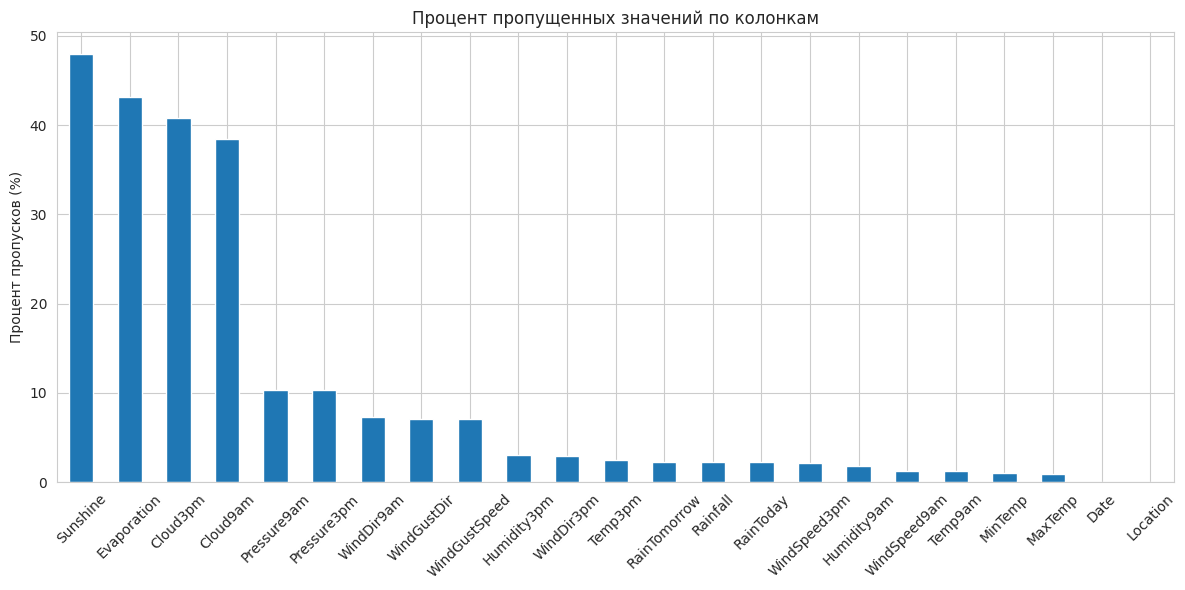

In [8]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent = null_percent.sort_values(ascending=False)
print("Процент пропусков по колонкам:")
print(null_percent)

plt.figure(figsize=(12, 6))
null_percent.plot(kind='bar')
plt.title('Процент пропущенных значений по колонкам')
plt.ylabel('Процент пропусков (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
df_clean = df.copy()
# колонки с большими пропусками (Evaporation (43%), Sunshine (48%), Cloud9am (38%), Cloud3pm (41%))
# удалить нельзя, всё-таки тучи/солнце важный признак в предсказывании дождя

cols_with_many_nans = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']

df_clean['Date'] = pd.to_datetime(df_clean['Date']) 
df_clean['Month'] = df_clean['Date'].dt.month

for col in cols_with_many_nans:
    global_median = df_clean[col].median()
    df_clean[col] = df_clean.groupby(['Location', 'Month'])[col].transform(
        lambda x: x.fillna(x.median())
    ).fillna(global_median)


# колонки с небольшим количеством пропусков (Pressure9am (10.3%), Pressure3pm (10.3%))
# заполняем медианой по локации
for col in ['Pressure9am', 'Pressure3pm']:
    global_median = df_clean[col].median()
    df_clean[col] = df_clean.groupby('Location')[col].transform(
        lambda x: x.fillna(x.median())
    ).fillna(global_median)

# колонки с малыми пропусками (MinTemp, MaxTemp, Rainfall, WindGustSpeed, WindSpeed9am, Humidity9am, Temp9am)

for col in ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']:
    # считаем глобальную медиану по всей таблице
    global_median = df_clean[col].median()
    # сначала пытаемся взять медиану по группе, если NaN остался — берем глобальную
    df_clean[col] = df_clean.groupby('Location')[col].transform(
        lambda x: x.fillna(x.median())
    ).fillna(global_median)

for col in ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm']:
    global_median = df_clean[col].median()
    df_clean[col] = df_clean.groupby('Location')[col].transform(
        lambda x: x.fillna(x.median())
    ).fillna(global_median)
# если Rainfall NaN, значит, дождя не было
df_clean['Rainfall'] = df_clean['Rainfall'].fillna(0)

# RainToday заполняем модой
df_clean['RainToday'] = df_clean['RainToday'].fillna(df_clean['RainToday'].mode()[0])
# RainTomorrow оставляем для целевой переменной, если есть пропуски - удаляем эти строки
df_clean = df_clean.dropna(subset=['RainTomorrow'])


# заполняем модой по локации и времени года
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    df_clean[col] = df_clean.groupby('Location')[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
    )

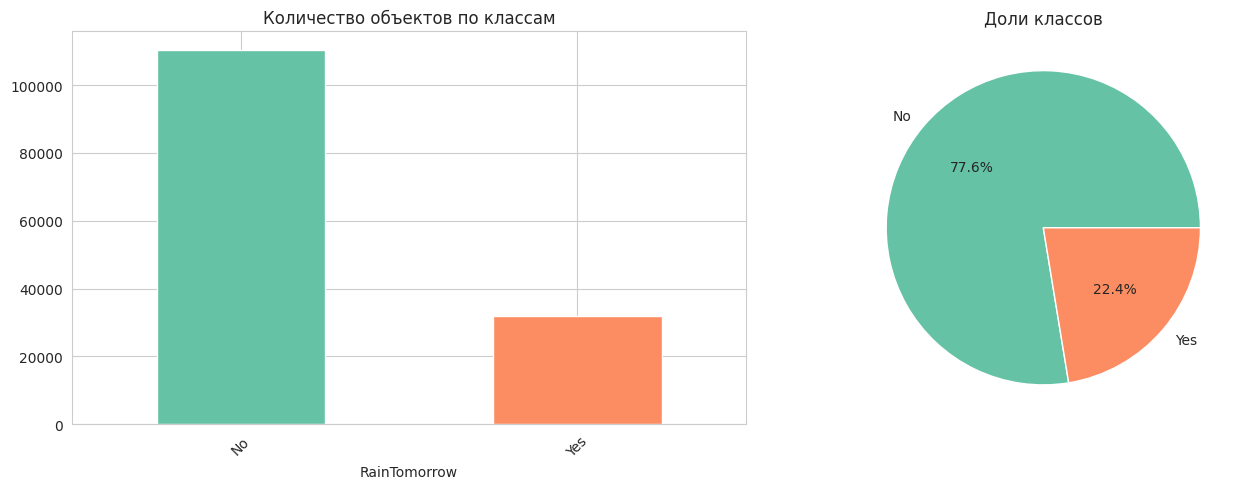

In [10]:
target_col = 'RainTomorrow'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

Распределения признаков

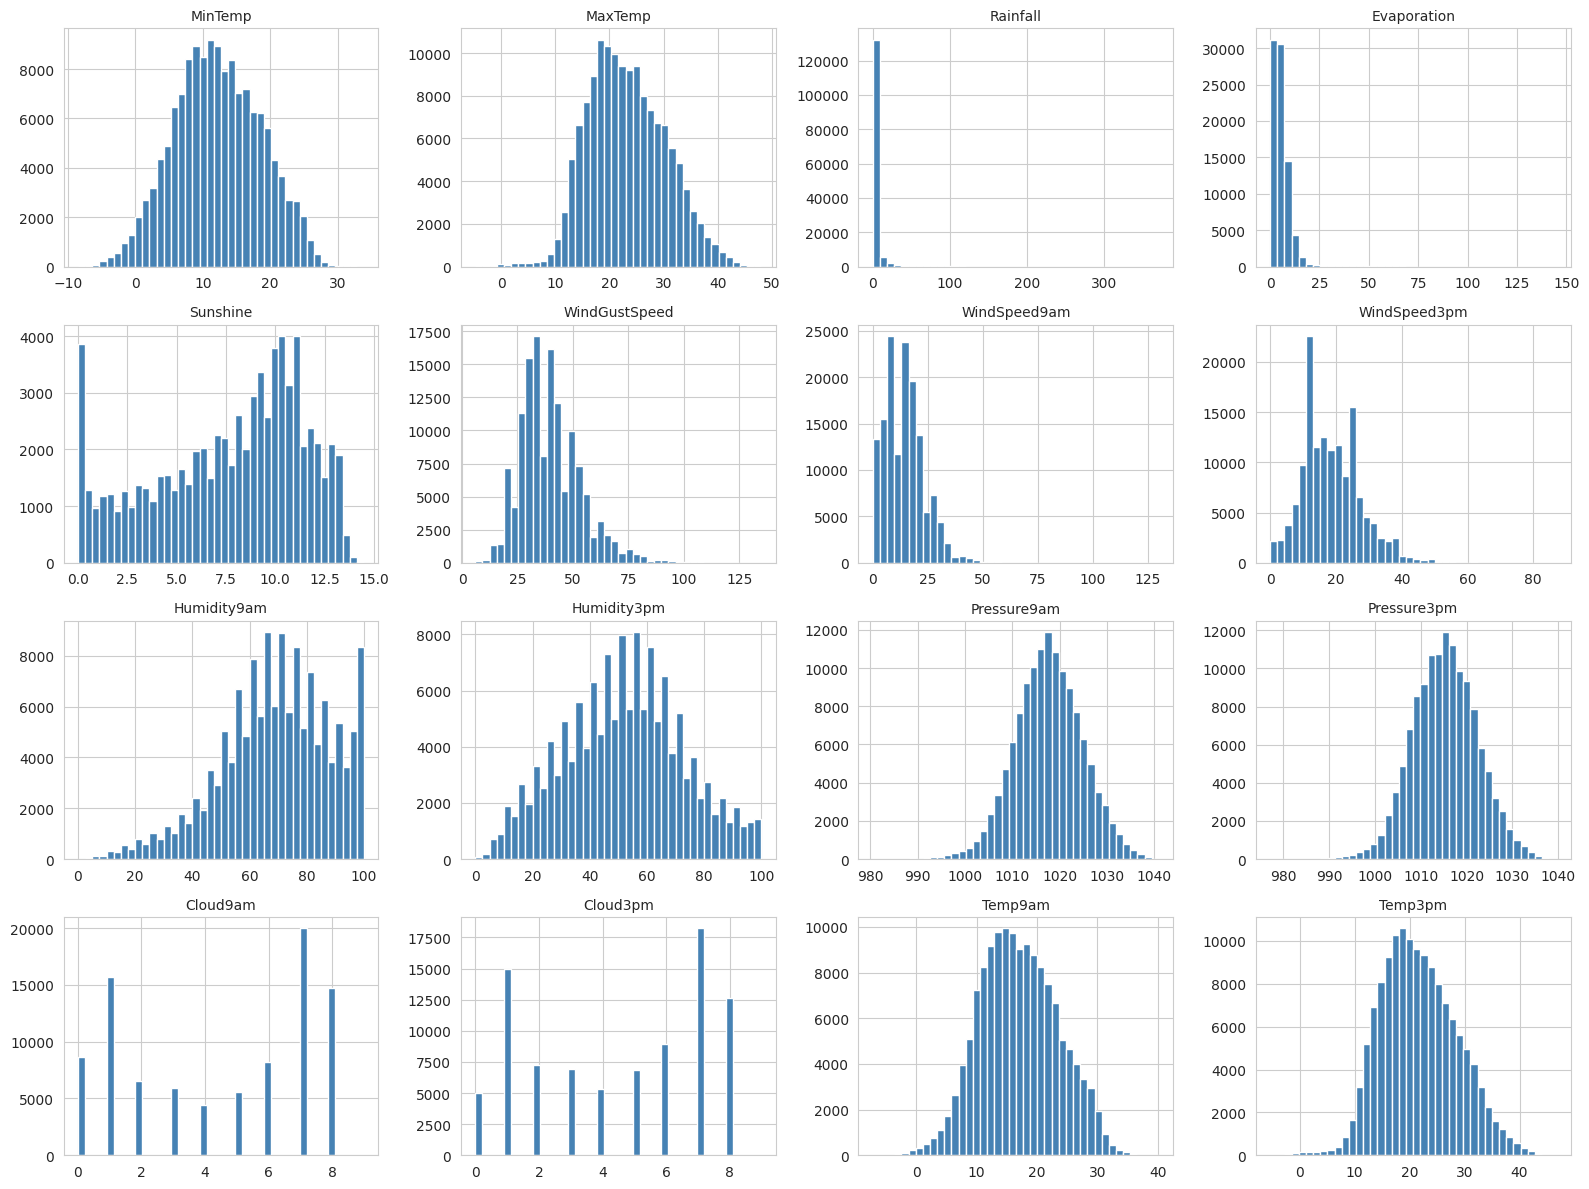

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

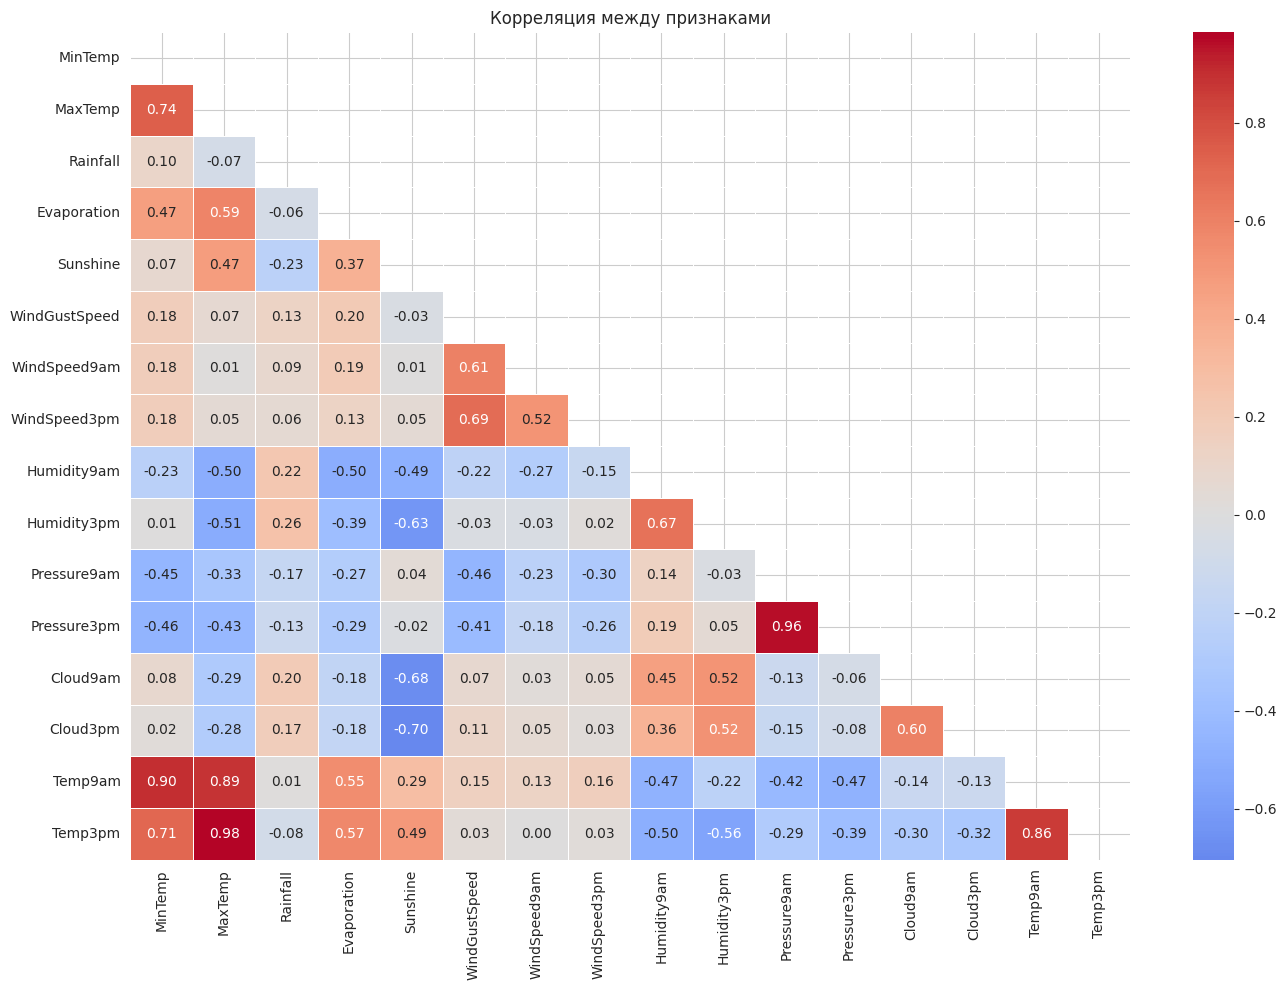

In [12]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

Boxplot признаков по классам

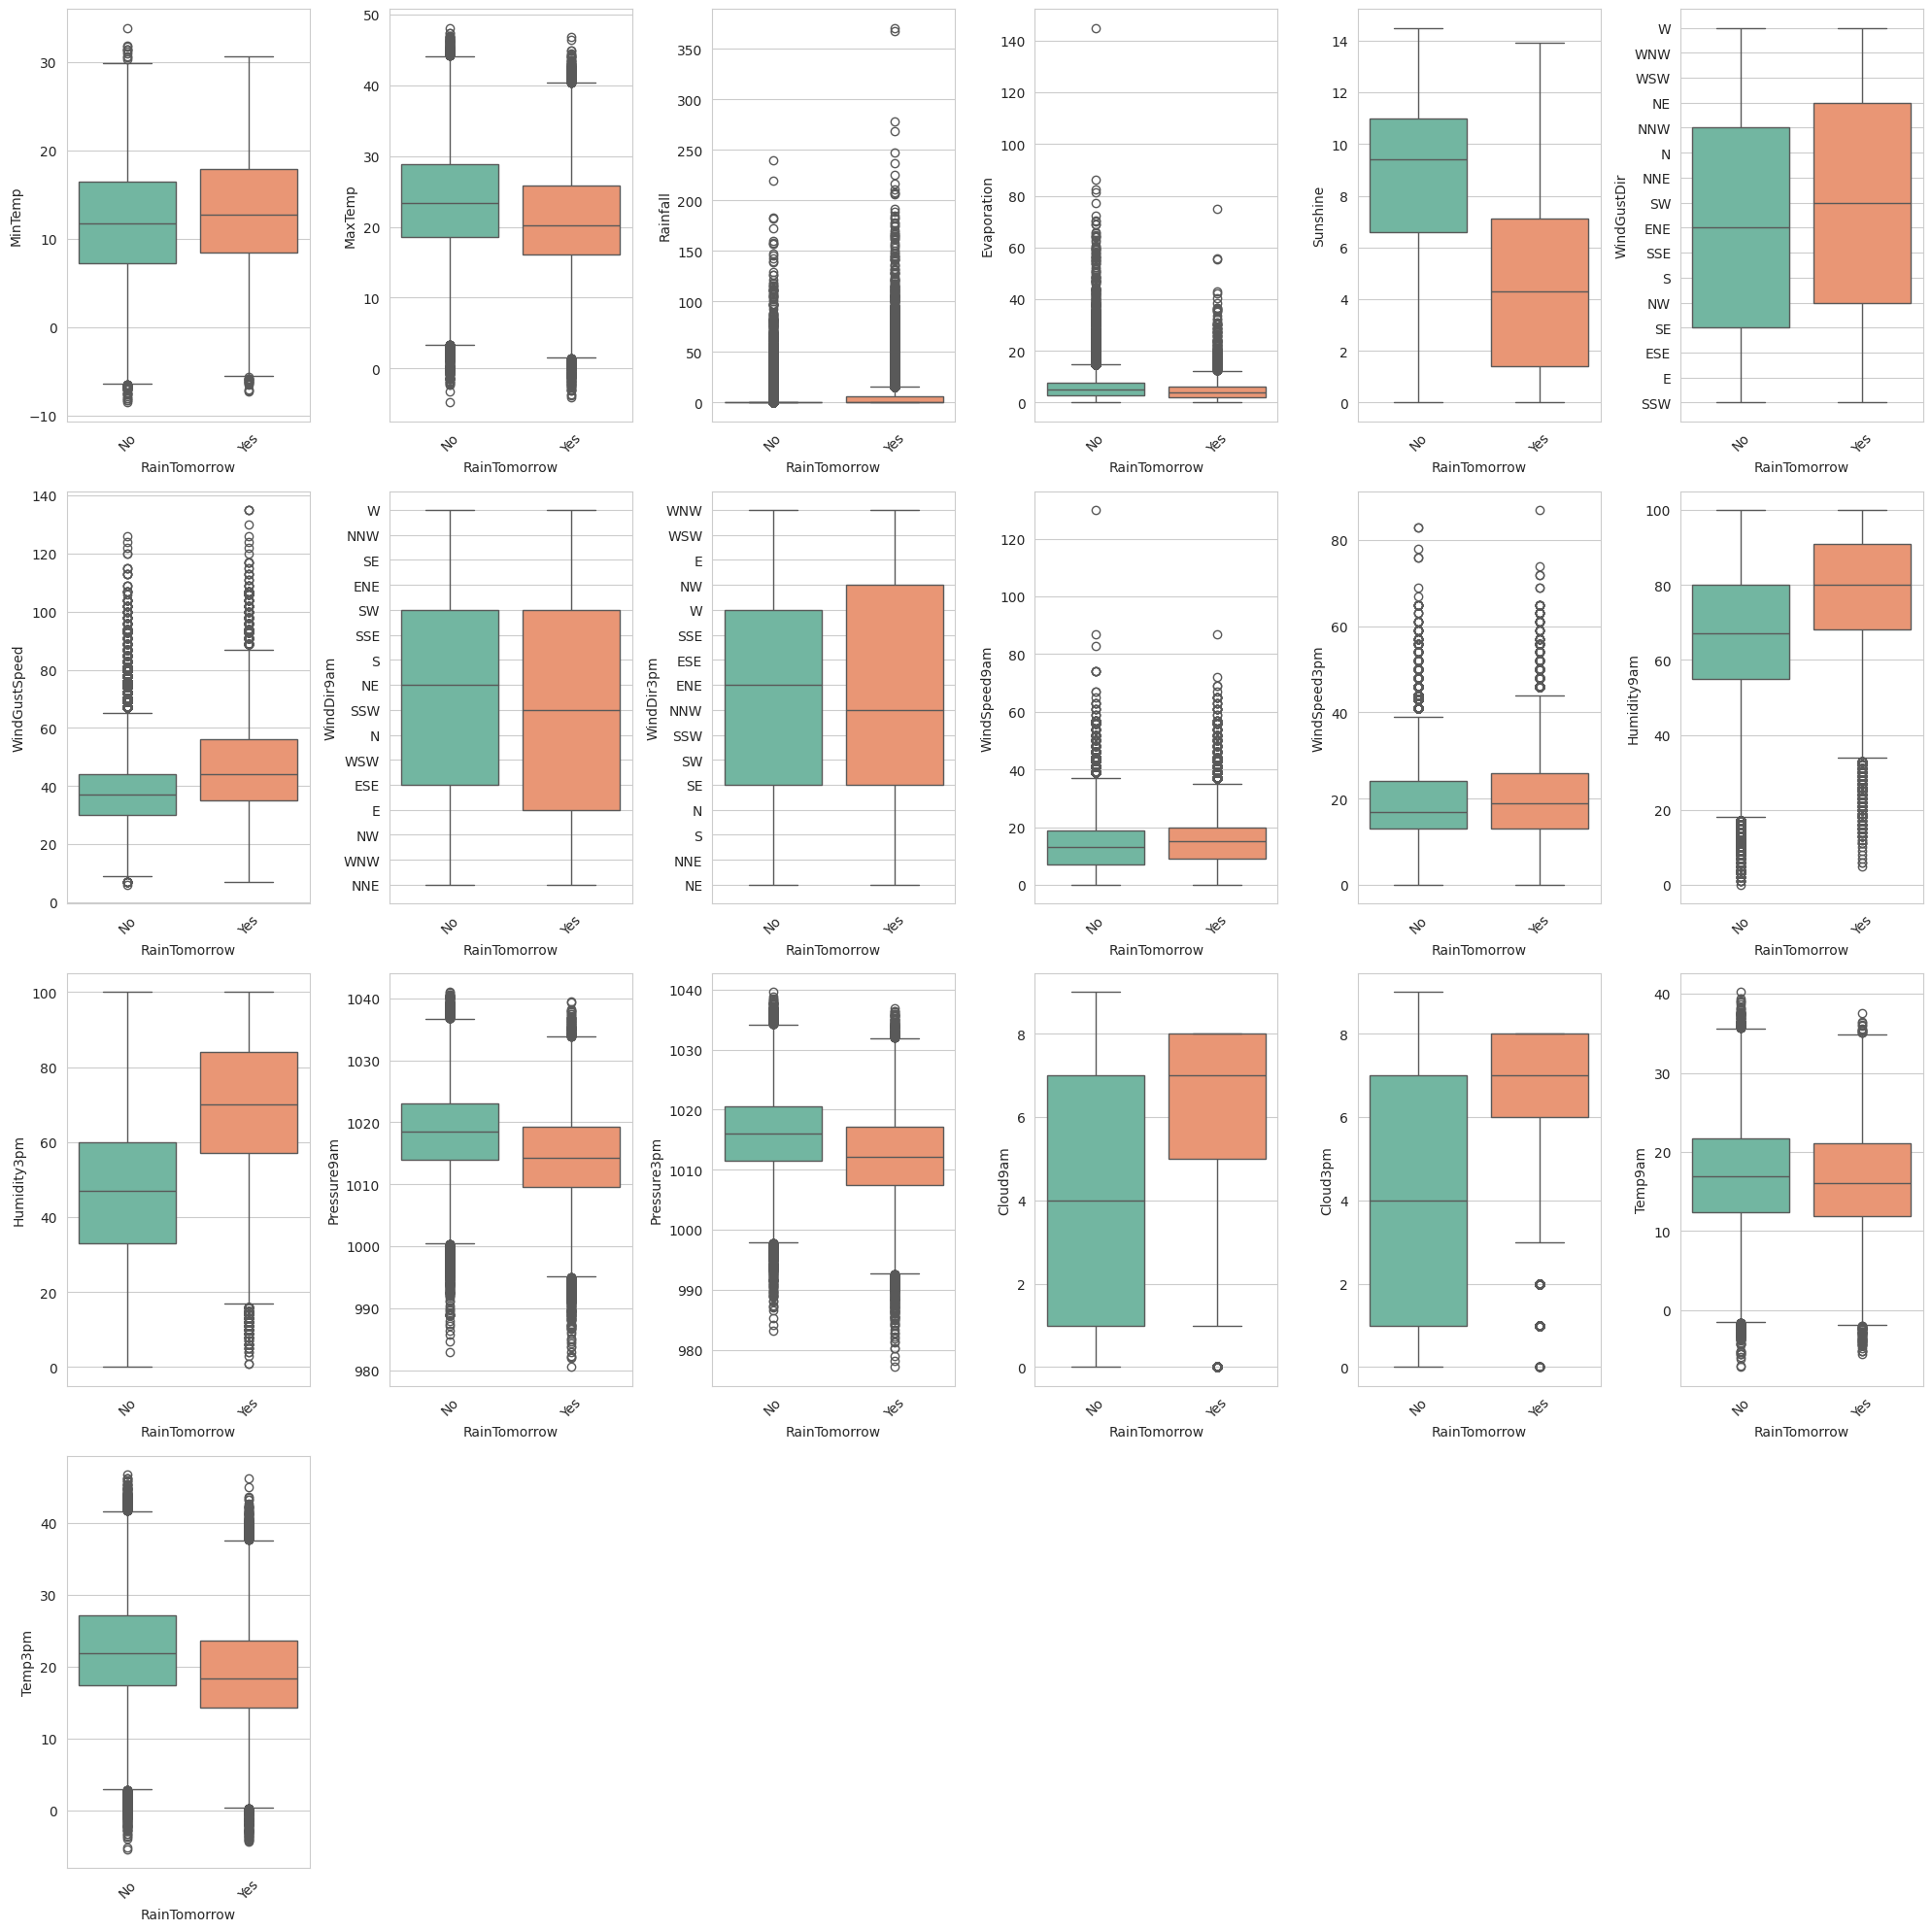

In [13]:
fig, axes = plt.subplots(4, 6, figsize=(20, 20))

flat_axes = axes.flatten()
top_features = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
for idx, col in enumerate(top_features):
    ax = flat_axes[idx] 
    sns.boxplot(data=df, x=target_col, y=col, ax=ax, palette='Set2')
    ax.tick_params(axis='x', rotation=45)

for idx in range(len(top_features), len(flat_axes)):
    flat_axes[idx].axis('off')
    
plt.tight_layout()
plt.show()

Pairplot (ключевые признаки)

In [14]:
# sns.pairplot(df[['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', target_col]], hue=target_col, palette='Set2', plot_kws={'alpha': 0.4, 's': 15})
# plt.show()

**Гипотезы**:
1. Логистическая регрессия с L1-регуляризацией обойдет по качеству логистическую регрессию с L2-регуляризацией (признаков много, было бы неплохо что-то занулить)
2. Базовая логистическая регрессия будет хуже модели с L1/L2 регуляризацией из-за наличия мультиколлинеарности в данных
3. Преобразование признака Rainfall в бинарный признак RainToday_Binary (был дождь или нет) даст лучший прирост в качестве предсказания RainTomorrow, чем использование исходного числового признака с выбросами
4. Температура окажется менее значимой, чем признаки, связанные с облачностью и влажностью для предсказания дождя (это мы проверим с помощью коэффициентов логистической регрессии, variance threshold, RFE) 
5. При удалении Pressure3am или Pressurepam (корреляция 0.96) и Temp3am или Temp9pm (корреляция 0.86) предсказания модели улучшатся
6. Random Forest с бустингом справится лучше, чем логистическая регресия с регуляризацией

In [15]:
print(df_clean.head())

        Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0 2008-12-01   Albury     13.4     22.9       0.6          4.8       8.4   
1 2008-12-02   Albury      7.4     25.1       0.0          4.8       8.4   
2 2008-12-03   Albury     12.9     25.7       0.0          4.8       8.4   
3 2008-12-04   Albury      9.2     28.0       0.0          4.8       8.4   
4 2008-12-05   Albury     17.5     32.3       1.0          4.8       8.4   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity3pm  Pressure9am  \
0           W           44.0          W  ...        22.0       1007.7   
1         WNW           44.0        NNW  ...        25.0       1010.6   
2         WSW           46.0          W  ...        30.0       1007.6   
3          NE           24.0         SE  ...        16.0       1017.6   
4           W           41.0        ENE  ...        33.0       1010.8   

   Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  RainTomorrow  \
0       1007.1       8.

**Блок обработки данных:**

In [16]:
print(df['Location'].unique())

['Albury' 'BadgerysCreek' 'Cobar' 'CoffsHarbour' 'Moree' 'Newcastle'
 'NorahHead' 'NorfolkIsland' 'Penrith' 'Richmond' 'Sydney' 'SydneyAirport'
 'WaggaWagga' 'Williamtown' 'Wollongong' 'Canberra' 'Tuggeranong'
 'MountGinini' 'Ballarat' 'Bendigo' 'Sale' 'MelbourneAirport' 'Melbourne'
 'Mildura' 'Nhil' 'Portland' 'Watsonia' 'Dartmoor' 'Brisbane' 'Cairns'
 'GoldCoast' 'Townsville' 'Adelaide' 'MountGambier' 'Nuriootpa' 'Woomera'
 'Albany' 'Witchcliffe' 'PearceRAAF' 'PerthAirport' 'Perth' 'SalmonGums'
 'Walpole' 'Hobart' 'Launceston' 'AliceSprings' 'Darwin' 'Katherine'
 'Uluru']


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df_clean = df.copy()
# колонки с большими пропусками (Evaporation (43%), Sunshine (48%), Cloud9am (38%), Cloud3pm (41%))
# удалить нельзя, всё-таки тучи/солнце важный признак в предсказывании дождя

cols_with_many_nans = ['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm']

df_clean['Date'] = pd.to_datetime(df_clean['Date']) 
df_clean['Month'] = df_clean['Date'].dt.month

for col in cols_with_many_nans:
    global_median = df_clean[col].median()
    df_clean[col] = df_clean.groupby(['Location', 'Month'])[col].transform(
        lambda x: x.fillna(x.median())
    ).fillna(global_median)


# колонки с небольшим количеством пропусков (Pressure9am (10.3%), Pressure3pm (10.3%))
# заполняем медианой по локации
for col in ['Pressure9am', 'Pressure3pm']:
    global_median = df_clean[col].median()
    df_clean[col] = df_clean.groupby('Location')[col].transform(
        lambda x: x.fillna(x.median())
    ).fillna(global_median)

# колонки с малыми пропусками (MinTemp, MaxTemp, Rainfall, WindGustSpeed, WindSpeed9am, Humidity9am, Temp9am)

for col in ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']:
    # считаем глобальную медиану по всей таблице
    global_median = df_clean[col].median()
    # сначала пытаемся взять медиану по группе, если NaN остался — берем глобальную
    df_clean[col] = df_clean.groupby('Location')[col].transform(
        lambda x: x.fillna(x.median())
    ).fillna(global_median)

for col in ['WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm']:
    global_median = df_clean[col].median()
    df_clean[col] = df_clean.groupby('Location')[col].transform(
        lambda x: x.fillna(x.median())
    ).fillna(global_median)
# если Rainfall NaN, значит, дождя не было
df_clean['Rainfall'] = df_clean['Rainfall'].fillna(0)

# RainToday заполняем модой
df_clean['RainToday'] = df_clean['RainToday'].fillna(df_clean['RainToday'].mode()[0])
# RainTomorrow оставляем для целевой переменной, если есть пропуски - удаляем эти строки
df_clean = df_clean.dropna(subset=['RainTomorrow'])


# заполняем модой по локации и времени года
for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    df_clean[col] = df_clean.groupby('Location')[col].transform(
        lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
    )



df_clean['RainTomorrow'] = df_clean['RainTomorrow'].map({'No': 0, 'Yes': 1})

# направления ветра будут градусами
dir_to_deg = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5
}

for col in ['WindGustDir', 'WindDir9am', 'WindDir3pm']:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.upper()
    df_clean[col] = df_clean[col].replace('UNKNOWN', np.nan)
    df_clean[col] = df_clean[col].map(dir_to_deg)
    df_clean[col] = df_clean[col].fillna(df_clean.groupby('Location')[col].transform('median'))
    global_median = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(global_median)
    
# для категориального признака Location применим географическую кластеризацию
city_coords = {
    'Albury': (-36.0748, 146.9240),
    'BadgerysCreek': (-33.8846, 150.7370),
    'Cobar': (-31.4983, 145.8344),
    'CoffsHarbour': (-30.2963, 153.1135),
    'Moree': (-29.4628, 149.8416),
    'Newcastle': (-32.9283, 151.7817),
    'NorahHead': (-33.2816, 151.5738),
    'NorfolkIsland': (-29.0408, 167.9547),
    'Penrith': (-33.7501, 150.6921),
    'Richmond': (-33.5987, 150.7514),
    'Sydney': (-33.8688, 151.2093),
    'SydneyAirport': (-33.9461, 151.1772),
    'WaggaWagga': (-35.1084, 147.3583),
    'Williamtown': (-32.8181, 151.8330),
    'Wollongong': (-34.4245, 150.8932),
    'Canberra': (-35.2809, 149.1300),
    'Tuggeranong': (-35.4178, 149.0660),
    'MountGinini': (-35.5217, 148.7725),
    'Ballarat': (-37.5608, 143.8500),
    'Bendigo': (-36.7588, 144.2802),
    'Sale': (-38.1100, 147.0700),
    'MelbourneAirport': (-37.6733, 144.8438),
    'Melbourne': (-37.8136, 144.9631),
    'Mildura': (-34.2112, 142.1333),
    'Nhil': (-36.1357, 142.2339),
    'Portland': (-38.3353, 141.6026),
    'Watsonia': (-37.7029, 145.0821),
    'Dartmoor': (-37.9333, 141.2833),
    'Brisbane': (-27.4698, 153.0251),
    'Cairns': (-16.9200, 145.7700),
    'GoldCoast': (-28.0167, 153.4000),
    'Townsville': (-19.2588, 146.8182),
    'Adelaide': (-34.9285, 138.6007),
    'MountGambier': (-37.8300, 140.7800),
    'Nuriootpa': (-34.4677, 138.9990),
    'Woomera': (-31.2000, 136.8300),
    'Albany': (-35.0275, 117.8842),
    'Witchcliffe': (-34.0251, 115.0998),
    'PearceRAAF': (-31.6670, 116.0130),
    'PerthAirport': (-31.9400, 115.9660),
    'Perth': (-31.9505, 115.8605),
    'SalmonGums': (-32.9817, 121.6448),
    'Walpole': (-34.9768, 116.7336),
    'Hobart': (-42.8821, 147.3272),
    'Launceston': (-41.4392, 147.1380),
    'AliceSprings': (-23.6987, 133.8807),
    'Darwin': (-12.4634, 130.8456),
    'Katherine': (-14.4652, 132.2635),
    'Uluru': (-25.3444, 131.0369)
}
df_clean['Lat'] = df_clean['Location'].map(lambda x: city_coords[x][0])
df_clean['Lon'] = df_clean['Location'].map(lambda x: city_coords[x][1])
coords = df_clean[['Lat', 'Lon']]

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
# предсказываем номер кластера для каждого города
df_clean['GeoZone'] = kmeans.fit_predict(coords)




feature_cols = ['MinTemp', 'MaxTemp', 'Rainfall', 'GeoZone', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'Month', 'RainTomorrow']
X_all = df_clean[feature_cols].copy()


df_clean = df_clean.sort_values(by='Date')
split_index = int(len(df_clean) * 0.8)
train_df = df_clean.iloc[:split_index]
test_df = df_clean.iloc[split_index:]

X_train_log_reg = train_df[feature_cols].drop(columns=['RainTomorrow'])
y_train_log_reg = train_df['RainTomorrow'].values

X_test_log_reg = test_df[feature_cols].drop(columns=['RainTomorrow'])
y_test_log_reg = test_df['RainTomorrow'].values

scaler_log_reg = StandardScaler()
X_train_log_reg_sc = scaler_log_reg.fit_transform(X_train_log_reg)
X_test_log_reg_sc = scaler_log_reg.transform(X_test_log_reg)  

Подбор числа кластеров в k-Means:

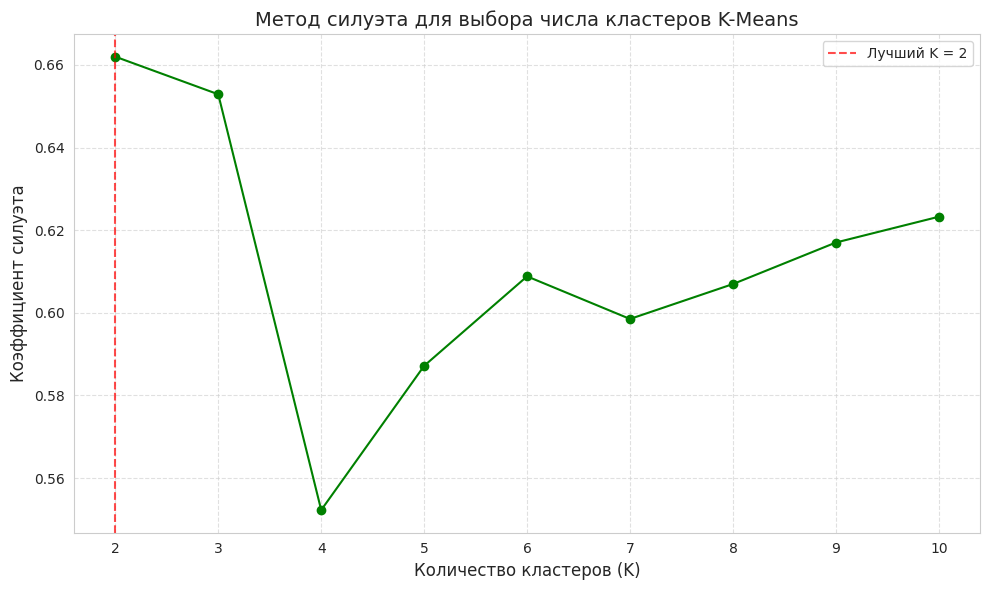

Коэффициенты силуэта для K=2..10: {2: np.float64(0.6619870295676523), 3: np.float64(0.6528836624819541), 4: np.float64(0.5522453796843105), 5: np.float64(0.5871539703028854), 6: np.float64(0.6088120308744078), 7: np.float64(0.5985021005574704), 8: np.float64(0.6069512055453836), 9: np.float64(0.6170032985777728), 10: np.float64(0.6232485359384783)}

Оптимальное число кластеров: K = 2


In [18]:
from sklearn.metrics import silhouette_score

# sil_scores = []
# K_range = range(2, 11)  # Силуэт не считается для K=1

# for k in K_range:
#     kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
#     labels = kmeans_test.fit_predict(coords)
#     score = silhouette_score(coords, labels)
#     sil_scores.append(score)



sil_scores = []
K_range = range(2, 11) 
coords_sampled = df_clean[['Lat', 'Lon']].sample(frac=0.1, random_state=42)
for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_test.fit_predict(coords_sampled) 
    score = silhouette_score(coords_sampled, labels) 
    sil_scores.append(score)


plt.figure(figsize=(10, 6))
plt.plot(K_range, sil_scores, marker='o', linestyle='-', color='g')
plt.title('Метод силуэта для выбора числа кластеров K-Means', fontsize=14)
plt.xlabel('Количество кластеров (K)', fontsize=12)
plt.ylabel('Коэффициент силуэта', fontsize=12)
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.6)

best_k = K_range[sil_scores.index(max(sil_scores))]
plt.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Лучший K = {best_k}')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Коэффициенты силуэта для K=2..10: {dict(zip(K_range, sil_scores))}")
print(f"\nОптимальное число кластеров: K = {best_k}")

,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
LogReg (No penalty),0.8409,0.7282,0.4583,0.5626,0.8522,0.6677
LogReg L2 (C=100),0.8409,0.7282,0.4583,0.5626,0.8522,0.6677
LogReg L2 (C=1.0),0.8410,0.7284,0.4588,0.5630,0.8522,0.6677
LogReg L2 (C=0.5),0.8411,0.7286,0.4590,0.5632,0.8522,0.6677
LogReg L2 (C=0.01),0.8410,0.7293,0.4575,0.5623,0.8517,0.6676
LogReg L1 (C=100),0.8411,0.7288,0.4585,0.5629,0.8522,0.6676
LogReg L1 (C=1.0),0.8411,0.7288,0.4585,0.5629,0.8522,0.6676
LogReg L1 (C=0.5),0.8411,0.7289,0.4583,0.5628,0.8522,0.6676
LogReg L1 (C=0.1),0.8410,0.7284,0.4585,0.5628,0.8521,0.6676


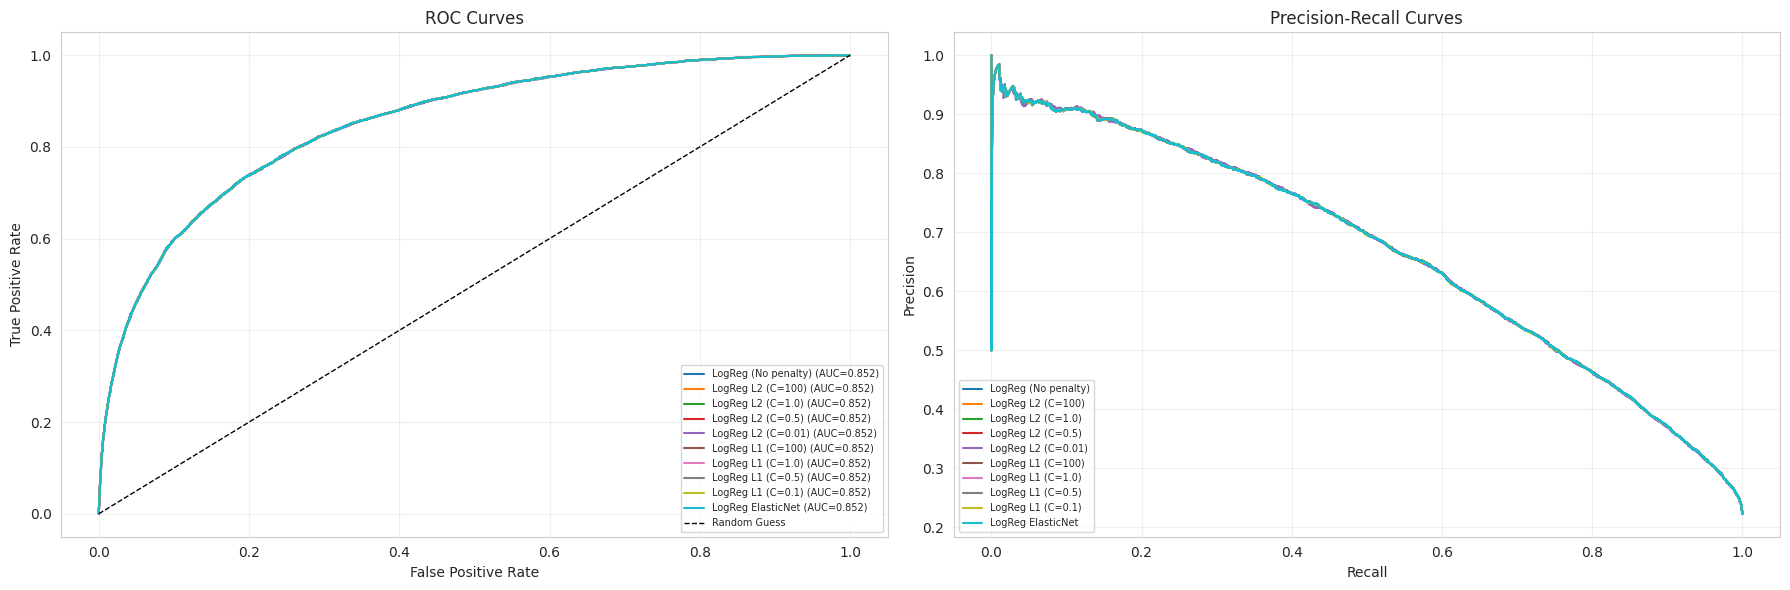

Variance Threshold
Признаков оставлено: 21
Ни один признак не удален (дисперсия всех достаточно высокая).

RFE (Рекурсивное удаление) - Топ-10 признаков


,Feature,RFE_Rank
3,GeoZone,1
2,Rainfall,1
7,WindGustSpeed,1
5,Sunshine,1
12,Humidity9am,1
13,Humidity3pm,1
14,Pressure9am,1
11,WindSpeed3pm,1
15,Pressure3pm,1
17,Cloud3pm,1


10 самых влиятельных признаков (по коэффициентам логистической регрессии)


,Feature,Coefficient,Abs_Coeff
15,Pressure3pm,-1.226916,1.226916
13,Humidity3pm,1.107373,1.107373
14,Pressure9am,0.837633,0.837633
7,WindGustSpeed,0.679557,0.679557
5,Sunshine,-0.364831,0.364831
17,Cloud3pm,0.280019,0.280019
2,Rainfall,0.201814,0.201814
3,GeoZone,-0.197316,0.197316
12,Humidity9am,0.190797,0.190797
11,WindSpeed3pm,-0.190260,0.190260



Сравнение методов отбора


,Feature,By_LogReg_Coef,By_RFE_Select
0,MinTemp,NO,NO
1,MaxTemp,NO,NO
2,Rainfall,YES,YES
3,GeoZone,YES,YES
4,Evaporation,NO,NO
5,Sunshine,YES,YES
6,WindGustDir,NO,NO
7,WindGustSpeed,YES,YES
8,WindDir9am,NO,NO
9,WindDir3pm,NO,NO


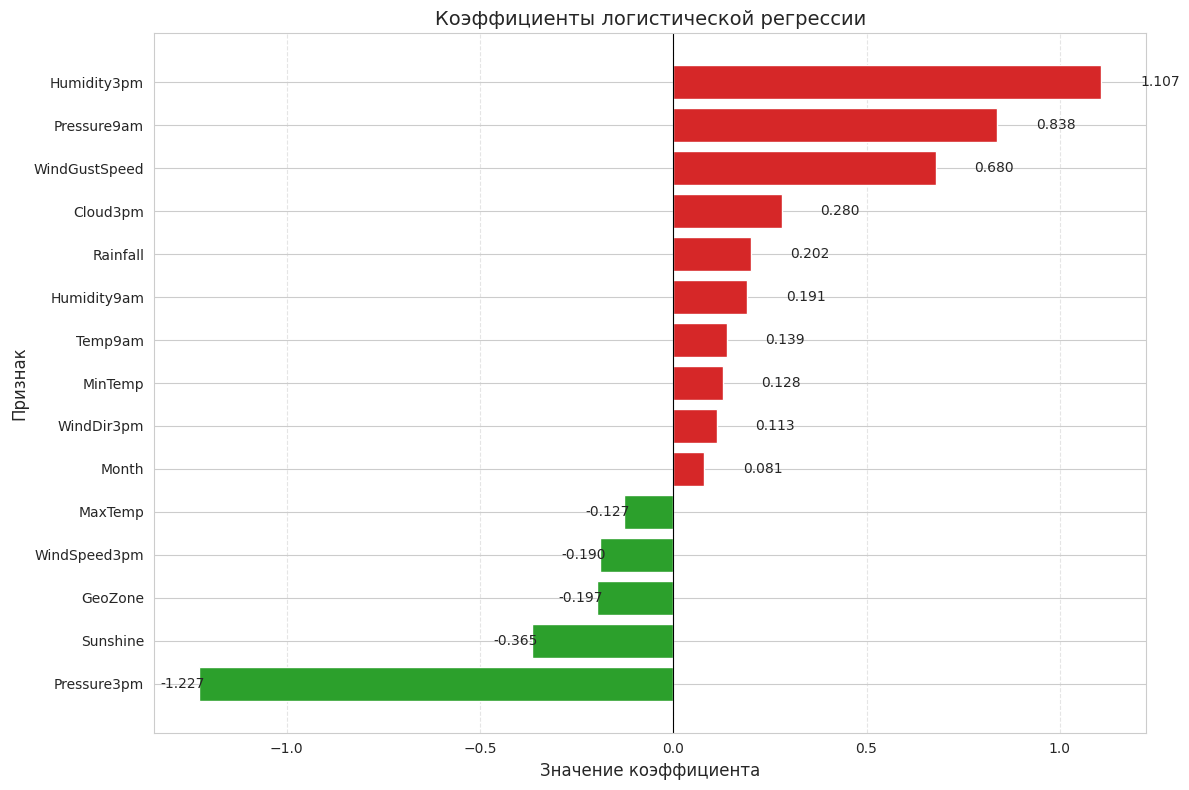

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold, RFE

models_log = {
    'LogReg (No penalty)': LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=42),
    'LogReg L2 (C=100)': LogisticRegression(penalty='l2', C=100, solver='lbfgs', max_iter=1000, random_state=42),
    'LogReg L2 (C=1.0)': LogisticRegression(penalty='l2', C=0.5, solver='lbfgs', max_iter=1000, random_state=42),
    'LogReg L2 (C=0.5)': LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42),
    'LogReg L2 (C=0.01)': LogisticRegression(penalty='l2', C=0.01, solver='lbfgs', max_iter=1000, random_state=42), 
    'LogReg L1 (C=100)': LogisticRegression(penalty='l1', C=100, solver='liblinear', max_iter=1000, random_state=42),
    'LogReg L1 (C=1.0)': LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=1000, random_state=42),
    'LogReg L1 (C=0.5)': LogisticRegression(penalty='l1', C=0.5, solver='liblinear', max_iter=1000, random_state=42),
    'LogReg L1 (C=0.1)': LogisticRegression(penalty='l1', C=0.1, solver='liblinear', max_iter=1000, random_state=42),
    'LogReg ElasticNet': LogisticRegression(penalty='elasticnet', C=1.0, l1_ratio=0.5, solver='saga', max_iter=1000, random_state=42)
}


results_log = []
roc_data = []  
pr_data = []   

for name, model in models_log.items():
    model.fit(X_train_log_reg_sc, y_train_log_reg)
    y_pred_class = model.predict(X_test_log_reg_sc)
    y_pred_proba = model.predict_proba(X_test_log_reg_sc)[:, 1]
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test_log_reg, y_pred_proba)
    pr_auc_value = auc(recall_vals, precision_vals)
    
    results_log.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_log_reg, y_pred_class),
        'Precision': precision_score(y_test_log_reg, y_pred_class),
        'Recall': recall_score(y_test_log_reg, y_pred_class),
        'F1-Score': f1_score(y_test_log_reg, y_pred_class),
        'ROC-AUC': roc_auc_score(y_test_log_reg, y_pred_proba), 
        'PR-AUC': pr_auc_value  
    })
    
    roc_data.append((name, roc_curve(y_test_log_reg, y_pred_proba)))
    pr_data.append((name, precision_vals, recall_vals))

display(pd.DataFrame(results_log).set_index('Model').round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for name, (fpr, tpr, _) in roc_data:
    axes[0].plot(fpr, tpr, lw=1.5, label=f'{name} (AUC={roc_auc_score(y_test_log_reg, y_pred_proba):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right', fontsize=7)
axes[0].grid(alpha=0.3)

for name, precision_vals, recall_vals in pr_data:
    axes[1].plot(recall_vals, precision_vals, lw=1.5, label=f'{name}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(loc='lower left', fontsize=7)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



# Проверяем гипотезу о важности признаков
best_model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
best_model.fit(X_train_log_reg_sc, y_train_log_reg)
# feature_names = feature_cols_exp1 if 'feature_cols_exp1' in locals() else feature_cols 
#feature_names = feature_cols
feature_names = [col for col in feature_cols if col != 'RainTomorrow']
coefficients = best_model.coef_[0]



# отбор признаков (Variance Threshold & RFE)


# Variance Threshold убирает признаки с очень низкой дисперсией.
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_train_log_reg_sc)
# True оставляем, False удаляем
var_mask = selector_var.get_support()
# список признаков, оставленных VarianceThreshold
features_kept_by_var = [feature_names[i] for i in range(len(feature_names)) if var_mask[i]]

features_removed_by_var = [feature_names[i] for i in range(len(feature_names)) if not var_mask[i]]

print("Variance Threshold")
print(f"Признаков оставлено: {len(features_kept_by_var)}")
if features_removed_by_var:
    print(f"Удалены (низкая дисперсия): {features_removed_by_var}")
else:
    print("Ни один признак не удален (дисперсия всех достаточно высокая).")


# 2. RFE рекурсивно удаляет наименее важные признаки
rfe = RFE(estimator=best_model, n_features_to_select=10)
rfe.fit(X_train_log_reg_sc, y_train_log_reg)

rfe_ranking = rfe.ranking_
rfe_support = rfe.support_

rfe_df = pd.DataFrame({
    'Feature': feature_names,
    'RFE_Rank': rfe_ranking,
    'Selected_Top10': rfe_support
}).sort_values(by='RFE_Rank')

print("\nRFE (Рекурсивное удаление) - Топ-10 признаков")
display(rfe_df[rfe_df['Selected_Top10'] == True][['Feature', 'RFE_Rank']])




coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df['Abs_Coeff'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values(by='Abs_Coeff', ascending=True)

print("10 самых влиятельных признаков (по коэффициентам логистической регрессии)")
display(coef_df.tail(10).sort_values(by='Abs_Coeff', ascending=False))




plt.figure(figsize=(12, 8))


# сравнение методов отбора
top10_coef_names = coef_df.tail(10).sort_values(by='Abs_Coeff', ascending=False)['Feature'].tolist()

print("\nСравнение методов отбора")
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'By_LogReg_Coef': ['YES' if f in top10_coef_names else 'NO' for f in feature_names],
    'By_RFE_Select': ['YES' if f in rfe_df[rfe_df['Selected_Top10'] == True]['Feature'].tolist() else 'NO' for f in feature_names]
})
display(comparison_df)


top_n = 15
plot_df = coef_df.tail(top_n).sort_values(by='Coefficient', ascending=True)

colors = ['#d62728' if c > 0 else '#2ca02c' for c in plot_df['Coefficient']]
plt.barh(plot_df['Feature'], plot_df['Coefficient'], color=colors)

plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.xlabel('Значение коэффициента', fontsize=12)
plt.ylabel('Признак', fontsize=12)
plt.title('Коэффициенты логистической регрессии', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for i, v in enumerate(plot_df['Coefficient']):
    plt.text(v + (0.1 if v > 0 else -0.1), i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

Таблица деревьев


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
DecisionTree (d=5),0.8315,0.7156,0.4066,0.5186,0.8151,0.6262
RandomForest (200),0.8509,0.7518,0.4954,0.5972,0.8736,0.7102
HistGradientBoosting,0.8531,0.7484,0.5146,0.6098,0.8740,0.7156



Лучшая логистическая регрессия: LogReg L2 (C=0.5)
Лучшее дерево: HistGradientBoosting


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
LogReg L2 (C=0.5),0.8411,0.7286,0.4590,0.5632,0.8522,0.6677
HistGradientBoosting,0.8531,0.7484,0.5146,0.6098,0.8740,0.7156


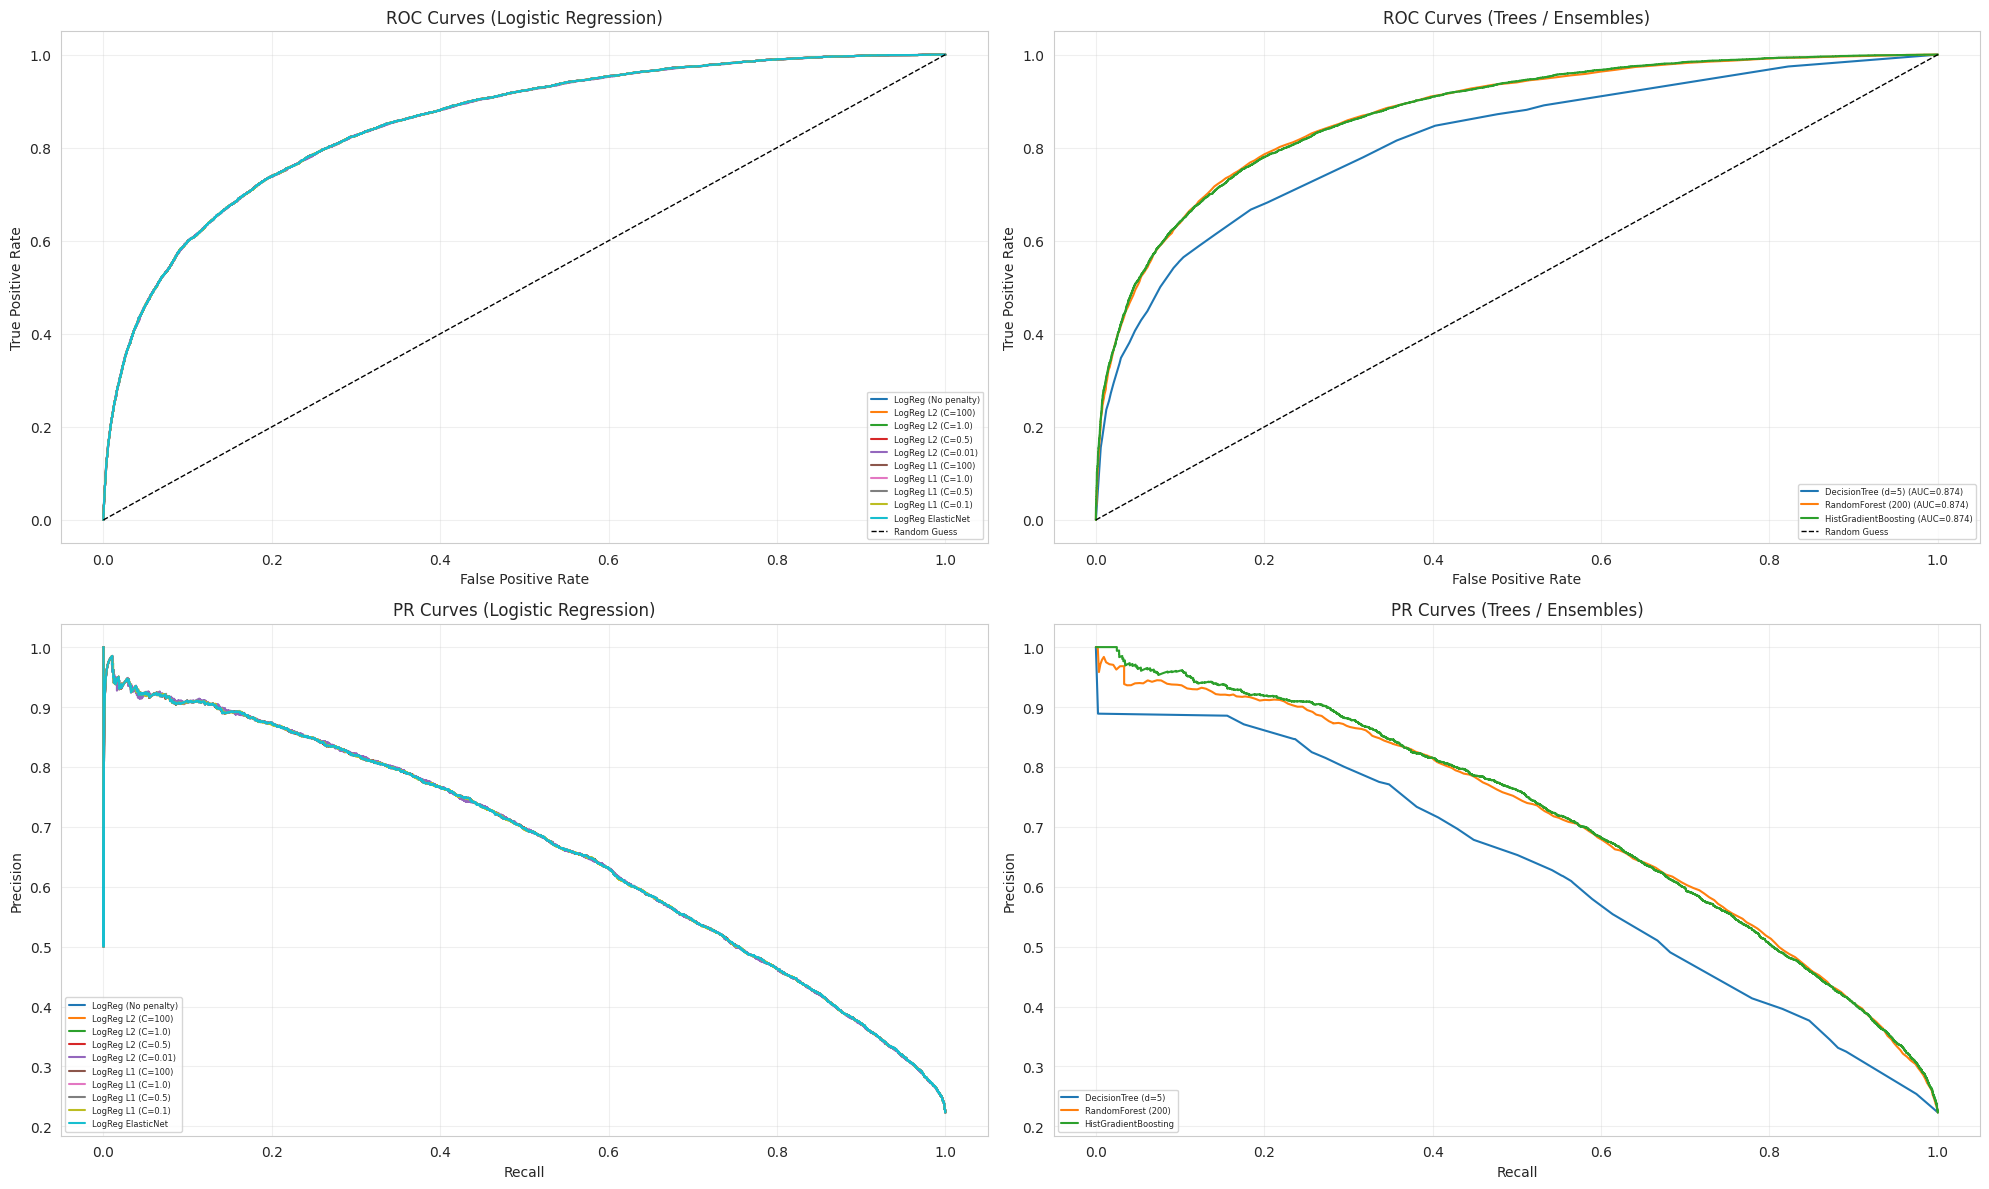

In [20]:
# деревья и ансамбли
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve, precision_recall_curve, auc

X_train_rf = train_df[feature_cols].drop(columns=['RainTomorrow'])
y_train_rf = train_df['RainTomorrow'].values

X_test_rf = test_df[feature_cols].drop(columns=['RainTomorrow'])
y_test_rf = test_df['RainTomorrow'].values

ensemble_models = {
    'DecisionTree (d=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
    'RandomForest (200)': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42, early_stopping=False),
}

ens_res = []
roc_data_ens = [] 
pr_data_ens = []  

for name, model in ensemble_models.items():
    model.fit(X_train_rf, y_train_rf)
    y_pred = model.predict(X_test_rf)
    y_pred_proba = model.predict_proba(X_test_rf)[:, 1] 
    
    acc = accuracy_score(y_test_rf, y_pred)
    prec = precision_score(y_test_rf, y_pred)
    rec = recall_score(y_test_rf, y_pred)
    f1 = f1_score(y_test_rf, y_pred)
    roc_auc = roc_auc_score(y_test_rf, y_pred_proba)
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test_rf, y_pred_proba)
    pr_auc = auc(recall_vals, precision_vals)
    
    ens_res.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'PR-AUC': pr_auc
    })
    
    roc_data_ens.append((name, roc_curve(y_test_rf, y_pred_proba)))
    pr_data_ens.append((name, precision_vals, recall_vals))

print("Таблица деревьев")
display(pd.DataFrame(ens_res).set_index('Model').round(4))

# лучшая логистическая регрессия по F1
best_log_name = pd.DataFrame(results_log).set_index('Model')['F1-Score'].idxmax()
best_log_res = [r for r in results_log if r['Model'] == best_log_name][0]

# лучшее дерево по F1
best_ens_name = pd.DataFrame(ens_res).set_index('Model')['F1-Score'].idxmax()
best_ens_res = [r for r in ens_res if r['Model'] == best_ens_name][0]

print(f"\nЛучшая логистическая регрессия: {best_log_name}")
print(f"Лучшее дерево: {best_ens_name}")
display(pd.DataFrame([best_log_res, best_ens_res]).set_index('Model').round(4))

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

for name, (fpr, tpr, _) in roc_data:
    axes[0, 0].plot(fpr, tpr, lw=1.5, label=f'{name}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curves (Logistic Regression)')
axes[0, 0].legend(loc='lower right', fontsize=6)
axes[0, 0].grid(alpha=0.3)

for name, precision_vals, recall_vals in pr_data:
    axes[1, 0].plot(recall_vals, precision_vals, lw=1.5, label=f'{name}')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('PR Curves (Logistic Regression)')
axes[1, 0].legend(loc='lower left', fontsize=6)
axes[1, 0].grid(alpha=0.3)

for name, (fpr, tpr, _) in roc_data_ens:
    axes[0, 1].plot(fpr, tpr, lw=1.5, label=f'{name} (AUC={roc_auc_score(y_test_rf, y_pred_proba):.3f})')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curves (Trees / Ensembles)')
axes[0, 1].legend(loc='lower right', fontsize=6)
axes[0, 1].grid(alpha=0.3)

for name, precision_vals, recall_vals in pr_data_ens:
    axes[1, 1].plot(recall_vals, precision_vals, lw=1.5, label=f'{name}')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('PR Curves (Trees / Ensembles)')
axes[1, 1].legend(loc='lower left', fontsize=6)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы (часть 1):** 

 
первая и вторая гипотеза не подтвердились (логистическая регрессия с L1-регуляризацией обойдет по качеству логистическую регрессию с L2-регуляризацией, базовая логистическая регрессия будет хуже модели с L1/L2 регуляризацией из-за наличия мультиколлинеарности в данных). Что с регуляризацией, что без неё, модель показывает примерно одинаковые результаты. Значит, данные хорошо очищены, мультиколлинеарность на так страшна для этой модели. Высокое значение Precision (больше, чем recall) говорит о том, что мы скорее не предскажем дождь (даже если он правда будет).  
Гипотеза о том, что температура окажется менее значимой, чем признаки, связанные с облачностью и влажностью для предсказания дождя, подтвердилась. Как показывают коэффициенты логистической регрессии, самые важные признаки - влажность, давление, скорость порыва ветра и облачность. 

Variance Threshold не удалил никакие признаки, самые важные признаки по мнению RFE и коэффициентов логистической регрессии практически совпадают, различие только в Temp9am (лог. регресссия) и GeoZone (RFE). 

Лучший результат показала модель HistGradientBoostingClassifier, баланс между Precision 0.7484 и Recal 0.5146, F1-Score (0.6098) и ROC-AUC (0.8740) среди всех протестированных алгоритмов, что делает её наиболее надежной для использования в реальных метеорологических задачах, то есть RandomForest с бустингом оказался лучше логистической регрессии.

Теперь проверим гипотезу о бинарном RainToday вместо числового RainFall.

Бинарный RainToday с регуляризацией


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
LogReg (No penalty),0.8408,0.7236,0.4643,0.5657,0.8534,0.6714
LogReg L2 (C=100),0.8408,0.7236,0.4643,0.5657,0.8534,0.6714
LogReg L2 (C=1.0),0.8409,0.7239,0.4645,0.5659,0.8534,0.6714
LogReg L2 (C=0.5),0.8408,0.7236,0.4643,0.5657,0.8534,0.6714
LogReg L2 (C=0.01),0.8406,0.7249,0.4612,0.5637,0.8529,0.6715
LogReg L1 (C=100),0.8408,0.7237,0.4640,0.5655,0.8534,0.6713
LogReg L1 (C=1.0),0.8408,0.7237,0.4640,0.5655,0.8534,0.6713
LogReg L1 (C=0.5),0.8408,0.7237,0.4642,0.5656,0.8534,0.6713
LogReg L1 (C=0.1),0.8409,0.7240,0.4640,0.5656,0.8533,0.6713



Сравнение: исходный график и бинарный


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
LogReg (Original Rainfall),0.8411,0.7286,0.4590,0.5632,0.8522,0.6677
LogReg (No penalty),0.8408,0.7236,0.4643,0.5657,0.8534,0.6714


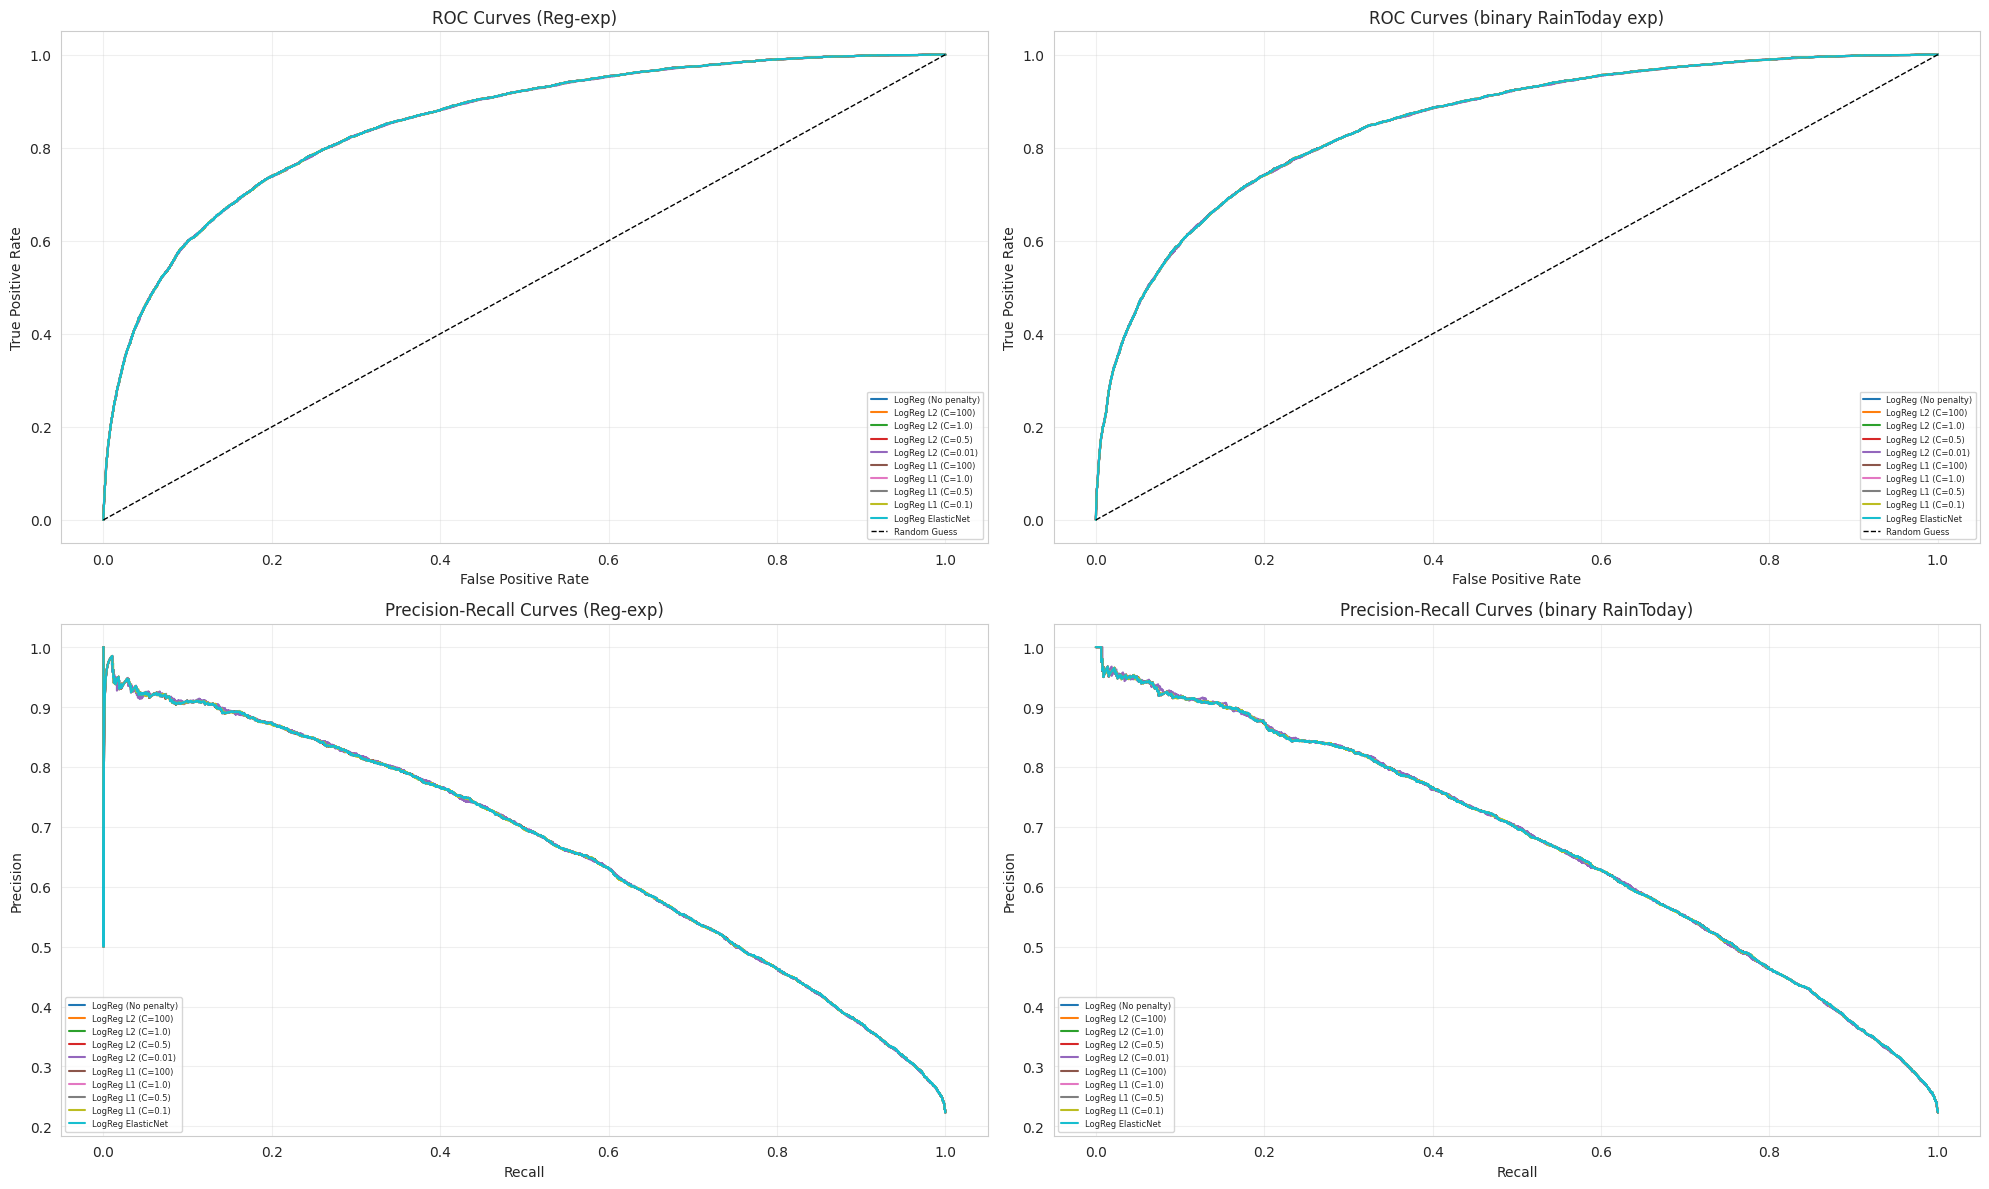

In [21]:
df_exp1 = df_clean.copy()

df_exp1['RainToday_Binary'] = (df_exp1['Rainfall'] >= 1).astype(int)

feature_cols_exp1 = ['MinTemp', 'MaxTemp', 'RainToday_Binary', 'GeoZone', 'Evaporation', 'Sunshine', 
                     'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 
                     'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 
                     'Temp9am', 'Temp3pm', 'Month']

df_exp1 = df_exp1.sort_values(by='Date')
split_idx = int(len(df_exp1) * 0.8)
train_exp1 = df_exp1.iloc[:split_idx]
test_exp1 = df_exp1.iloc[split_idx:]

X_train_exp1 = train_exp1[feature_cols_exp1]
y_train_exp1 = train_exp1['RainTomorrow'].values
X_test_exp1 = test_exp1[feature_cols_exp1]
y_test_exp1 = test_exp1['RainTomorrow'].values

scaler_exp1 = StandardScaler()
X_train_exp1_sc = scaler_exp1.fit_transform(X_train_exp1)
X_test_exp1_sc = scaler_exp1.transform(X_test_exp1)

results_bin = []
roc_data_bin = []  
pr_data_bin = []   

for name, model in models_log.items():
    model.fit(X_train_exp1_sc, y_train_exp1)
    y_pred_bin = model.predict(X_test_exp1_sc)
    y_pred_proba_bin = model.predict_proba(X_test_exp1_sc)[:, 1]
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test_exp1, y_pred_proba_bin)
    pr_auc_value = auc(recall_vals, precision_vals)
    
    results_bin.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_exp1, y_pred_bin),
        'Precision': precision_score(y_test_exp1, y_pred_bin),
        'Recall': recall_score(y_test_exp1, y_pred_bin),
        'F1-Score': f1_score(y_test_exp1, y_pred_bin),
        'ROC-AUC': roc_auc_score(y_test_exp1, y_pred_proba_bin), 
        'PR-AUC': pr_auc_value  
    })
    
    roc_data_bin.append((name, roc_curve(y_test_exp1, y_pred_proba_bin)))
    pr_data_bin.append((name, precision_vals, recall_vals))

print("Бинарный RainToday с регуляризацией")
display(pd.DataFrame(results_bin).set_index('Model').round(4))


model_original = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
model_original.fit(X_train_log_reg_sc, y_train_log_reg)
y_pred_orig = model_original.predict(X_test_log_reg_sc)
y_pred_proba_orig = model_original.predict_proba(X_test_log_reg_sc)[:, 1]

precision_orig, recall_orig, _ = precision_recall_curve(y_test_log_reg, y_pred_proba_orig)
fpr_orig, tpr_orig, _ = roc_curve(y_test_log_reg, y_pred_proba_orig)

results_original = {
    'Model': 'LogReg (Original Rainfall)',
    'Accuracy': accuracy_score(y_test_log_reg, y_pred_orig),
    'Precision': precision_score(y_test_log_reg, y_pred_orig),
    'Recall': recall_score(y_test_log_reg, y_pred_orig),
    'F1-Score': f1_score(y_test_log_reg, y_pred_orig),
    'ROC-AUC': roc_auc_score(y_test_log_reg, y_pred_proba_orig),
    'PR-AUC': auc(recall_orig, precision_orig) 
}

print("\nСравнение: исходный график и бинарный")
display(pd.DataFrame([results_original, results_bin[0]]).set_index('Model').round(4)) 


fig, axes = plt.subplots(2, 2, figsize=(20, 12))

for name, (fpr, tpr, _) in roc_data:
    axes[0, 0].plot(fpr, tpr, lw=1.5, label=f'{name}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curves (Reg-exp)')
axes[0, 0].legend(loc='lower right', fontsize=6)
axes[0, 0].grid(alpha=0.3)

for name, precision_vals, recall_vals in pr_data:
    axes[1, 0].plot(recall_vals, precision_vals, lw=1.5, label=f'{name}')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curves (Reg-exp)')
axes[1, 0].legend(loc='lower left', fontsize=6)
axes[1, 0].grid(alpha=0.3)

for name, (fpr, tpr, _) in roc_data_bin:
    axes[0, 1].plot(fpr, tpr, lw=1.5, label=f'{name}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curves (binary RainToday exp)')
axes[0, 1].legend(loc='lower right', fontsize=6)
axes[0, 1].grid(alpha=0.3)

for name, precision_vals, recall_vals in pr_data_bin:
    axes[1, 1].plot(recall_vals, precision_vals, lw=1.5, label=f'{name}')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision-Recall Curves (binary RainToday)')
axes[1, 1].legend(loc='lower left', fontsize=6)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы (часть 2):** 

третья гипотеза про бинарный признак подтвердилась частично. Несмотря на незначительное снижение Accuracy (с 84.11% до 84.04%) и Precision (с 72.94% до 72.41%), модель улучшила Recall (вырос с 45.82% до 46.09%), и ROC-AUC (увеличился с 0.8521 до 0.8533).
Таким образом, гипотеза о том, что бинаризация улучшит качество, подтвердилась в части устойчивости модели к редким событиям, но глобального улучшения точности не произошло, что говорит о достаточной линейной разделимости исходных данных. 
Теперь проверим гипотезу об удалении мультиколлинеарных признаков.


 Удалены Pressure3pm и Temp3pm (с регуляризацией)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
LogReg (No penalty),0.8372,0.7137,0.4524,0.5537,0.8444,0.6611
LogReg L2 (C=100),0.8372,0.7137,0.4524,0.5537,0.8444,0.6611
LogReg L2 (C=1.0),0.8372,0.7136,0.4525,0.5538,0.8444,0.6611
LogReg L2 (C=0.5),0.8373,0.7138,0.4525,0.5539,0.8444,0.6611
LogReg L2 (C=0.01),0.8374,0.7153,0.4511,0.5533,0.8444,0.6612
LogReg L1 (C=100),0.8372,0.7135,0.4524,0.5537,0.8444,0.6611
LogReg L1 (C=1.0),0.8372,0.7135,0.4524,0.5537,0.8444,0.6611
LogReg L1 (C=0.5),0.8371,0.7134,0.4520,0.5534,0.8444,0.6611
LogReg L1 (C=0.1),0.8372,0.7138,0.4522,0.5537,0.8444,0.6611


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
LogReg (With Pressure3pm & Temp3pm),0.8408,0.7236,0.4643,0.5657,0.8534,0.6714
LogReg (No penalty),0.8372,0.7137,0.4524,0.5537,0.8444,0.6611


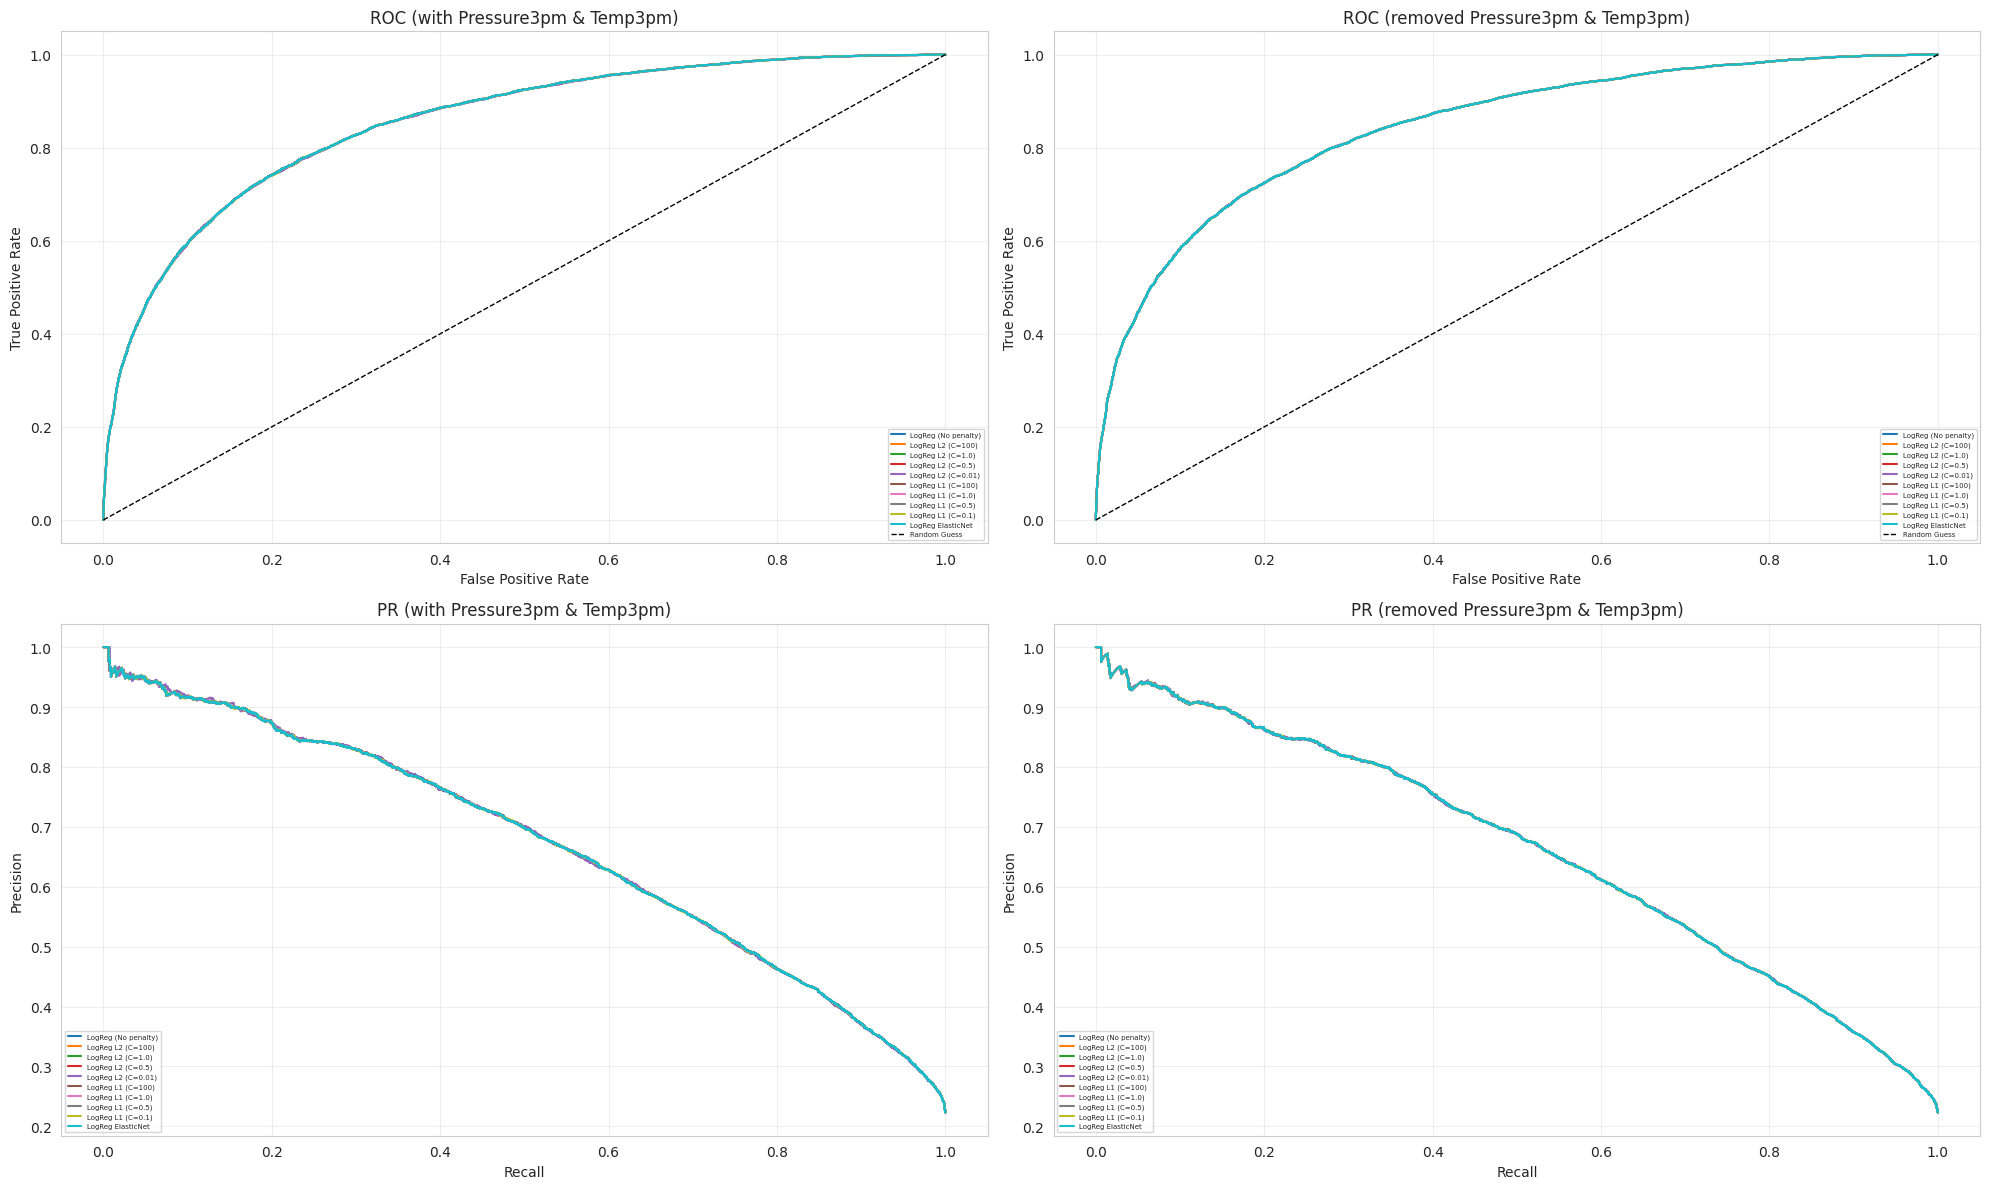

In [22]:

df_exp5 = df_clean.copy()

df_exp5['RainToday_Binary'] = (df_exp5['Rainfall'] >= 1).astype(int)

feature_cols_exp5 = ['MinTemp', 'MaxTemp', 'RainToday_Binary', 'GeoZone', 'Evaporation', 'Sunshine', 
                     'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 
                     'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Cloud9am', 'Cloud3pm', 
                     'Temp9am', 'Month'] 

df_exp5 = df_exp5.sort_values(by='Date')
split_idx = int(len(df_exp5) * 0.8)
train_exp5 = df_exp5.iloc[:split_idx]
test_exp5 = df_exp5.iloc[split_idx:]

X_train_exp5 = train_exp5[feature_cols_exp5]
y_train_exp5 = train_exp5['RainTomorrow'].values
X_test_exp5 = test_exp5[feature_cols_exp5]
y_test_exp5 = test_exp5['RainTomorrow'].values

scaler_exp5 = StandardScaler()
X_train_exp5_sc = scaler_exp5.fit_transform(X_train_exp5)
X_test_exp5_sc = scaler_exp5.transform(X_test_exp5)

results_exp5 = []
roc_data_exp5 = []  
pr_data_exp5 = []   

for name, model in models_log.items():
    model.fit(X_train_exp5_sc, y_train_exp5)
    y_pred_exp5 = model.predict(X_test_exp5_sc)
    y_pred_proba_exp5 = model.predict_proba(X_test_exp5_sc)[:, 1]
    
    precision_vals, recall_vals, _ = precision_recall_curve(y_test_exp5, y_pred_proba_exp5)
    pr_auc_value = auc(recall_vals, precision_vals)
    
    results_exp5.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test_exp5, y_pred_exp5),
        'Precision': precision_score(y_test_exp5, y_pred_exp5),
        'Recall': recall_score(y_test_exp5, y_pred_exp5),
        'F1-Score': f1_score(y_test_exp5, y_pred_exp5),
        'ROC-AUC': roc_auc_score(y_test_exp5, y_pred_proba_exp5), 
        'PR-AUC': pr_auc_value  
    })
    
    roc_data_exp5.append((name, roc_curve(y_test_exp5, y_pred_proba_exp5)))
    pr_data_exp5.append((name, precision_vals, recall_vals))

print(" Удалены Pressure3pm и Temp3pm (с регуляризацией)")
display(pd.DataFrame(results_exp5).set_index('Model').round(4))


model_baseline = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
model_baseline.fit(X_train_exp1_sc, y_train_exp1)
y_pred_baseline = model_baseline.predict(X_test_exp1_sc)
y_pred_proba_baseline = model_baseline.predict_proba(X_test_exp1_sc)[:, 1]

precision_baseline, recall_baseline, _ = precision_recall_curve(y_test_exp1, y_pred_proba_baseline)
fpr_baseline, tpr_baseline, _ = roc_curve(y_test_exp1, y_pred_proba_baseline)

results_baseline = {
    'Model': 'LogReg (With Pressure3pm & Temp3pm)',
    'Accuracy': accuracy_score(y_test_exp1, y_pred_baseline),
    'Precision': precision_score(y_test_exp1, y_pred_baseline),
    'Recall': recall_score(y_test_exp1, y_pred_baseline),
    'F1-Score': f1_score(y_test_exp1, y_pred_baseline),
    'ROC-AUC': roc_auc_score(y_test_exp1, y_pred_proba_baseline),
    'PR-AUC': auc(recall_baseline, precision_baseline) 
}

display(pd.DataFrame([results_baseline, results_exp5[0]]).set_index('Model').round(4)) 


# слева - эксп1 с дубликатами, справа - эксп5 без дубликатов
fig, axes = plt.subplots(2, 2, figsize=(20, 12))

for name, (fpr, tpr, _) in roc_data_bin:
    axes[0, 0].plot(fpr, tpr, lw=1.5, label=f'{name}')
axes[0, 0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC (with Pressure3pm & Temp3pm)')
axes[0, 0].legend(loc='lower right', fontsize=5)
axes[0, 0].grid(alpha=0.3)

for name, precision_vals, recall_vals in pr_data_bin:
    axes[1, 0].plot(recall_vals, precision_vals, lw=1.5, label=f'{name}')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('PR (with Pressure3pm & Temp3pm)')
axes[1, 0].legend(loc='lower left', fontsize=5)
axes[1, 0].grid(alpha=0.3)

for name, (fpr, tpr, _) in roc_data_exp5:
    axes[0, 1].plot(fpr, tpr, lw=1.5, label=f'{name}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Guess')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC (removed Pressure3pm & Temp3pm)')
axes[0, 1].legend(loc='lower right', fontsize=5)
axes[0, 1].grid(alpha=0.3)

for name, precision_vals, recall_vals in pr_data_exp5:
    axes[1, 1].plot(recall_vals, precision_vals, lw=1.5, label=f'{name}')
axes[1, 1].set_xlabel('Recall')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('PR (removed Pressure3pm & Temp3pm)')
axes[1, 1].legend(loc='lower left', fontsize=5)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Выводы (часть 3):**

Значит, гипотеза об удалении коллинеарных признаков тоже не подтвердилась, наоборот, по показателям модели видны ухудшения. Базовая модель, использующая все признаки (включая дублирующиеся), показала более высокие результаты: Accuracy снизился на 0.0033, Precision упал на 0.0088, а Recall — на 0.0111, ROC-AUC упал с 0.8533 до 0.8451, а F1-Score - с 0.5631 до 0.5522. 
Несмотря на высокую корреляцию (0.96 и 0.86), видимо, эти признаки содержали уникальную дополнительную информацию о суточном ходе погоды, простое удаление одного из признаков привело к потере этой информации и, как следствие, к снижению предсказательной силы модели.